In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# better visuals
sns.set_style("whitegrid")


In [8]:
df1 = pd.read_csv('../Data/Raw/netflix_titles.csv')
df2 = pd.read_csv(
    '../Data/Raw/mymoviedb.csv',
    engine='python',
    on_bad_lines='skip',
    encoding='latin1'
)


print("df1 columns:", df1.columns)
print("df2 columns:", df2.columns)


df1 columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
df2 columns: Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='str')


In [9]:
df2.rename(columns={
    'Title': 'title',
    'Genre': 'genre',
    'Overview': 'overview',
    'Popularity': 'popularity',
    'Vote_Count': 'vote_count',
    'Vote_Average': 'vote_average'
}, inplace=True)

In [10]:
print("df1 columns:")
print(df1.columns.tolist())

print("\ndf2 columns:")
print(df2.columns.tolist())

df1 columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

df2 columns:
['Release_Date', 'title', 'overview', 'popularity', 'vote_count', 'vote_average', 'Original_Language', 'genre', 'Poster_Url']


In [11]:
df = pd.merge(
    df1,
    df2,
    left_on='title',
    right_on='title',
    how='left'
)

In [12]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Release_Date,overview,popularity,vote_count,vote_average,Original_Language,genre,Poster_Url
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.shape

(8907, 20)

In [14]:
df.info() # use for check the column and datatype


<class 'pandas.DataFrame'>
RangeIndex: 8907 entries, 0 to 8906
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   show_id            8907 non-null   str    
 1   type               8907 non-null   str    
 2   title              8907 non-null   str    
 3   director           6260 non-null   str    
 4   cast               8080 non-null   str    
 5   country            8071 non-null   str    
 6   date_added         8897 non-null   str    
 7   release_year       8907 non-null   int64  
 8   rating             8903 non-null   str    
 9   duration           8904 non-null   str    
 10  listed_in          8907 non-null   str    
 11  description        8907 non-null   str    
 12  Release_Date       1773 non-null   str    
 13  overview           1773 non-null   str    
 14  popularity         1773 non-null   float64
 15  vote_count         1773 non-null   str    
 16  vote_average       1773 non-null   

In [15]:
df1.fillna('', inplace=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,,,,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,,,,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [16]:
# fill df1 (text)
df1.fillna('', inplace=True)

# convert numeric columns
num_cols = ['popularity', 'vote_count', 'vote_average']
for col in num_cols:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

# fill missing numeric values
df2[num_cols] = df2[num_cols].fillna(df2[num_cols].mean())


In [17]:
df1['tags'] = df1['director'] + ' ' + df1['cast'] + ' ' + df1['listed_in'] + ' ' + df1['description']
df2['tags'] = df2['genre'] + ' ' + df2['overview']

df1['tags'] = df1['tags'].str.lower()
df2['tags'] = df2['tags'].str.lower()

df = df1.merge(df2, on='title')

df.drop_duplicates(subset='title', inplace=True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,tags_x,Release_Date,overview,popularity,vote_count,vote_average,Original_Language,genre,Poster_Url,tags_y
0,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",,"September 24, 2021",2021,PG,91 min,...,"robert cullen, josé luis ucha vanessa hudgens,...",2021-09-23,Equestria's divided. But a bright-eyed hero be...,137.815,190.0,8.1,en,"Animation, Family, Fantasy, Comedy, Music, Adv...",https://image.tmdb.org/t/p/original/hzq5XRGgm6...,"animation, family, fantasy, comedy, music, adv..."
1,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,...,"theodore melfi melissa mccarthy, chris o'dowd,...",2021-09-17,A woman adjusting to life after a loss contend...,27.515,174.0,7.2,en,Drama,https://image.tmdb.org/t/p/original/gPkaPGNbjZ...,drama a woman adjusting to life after a loss c...
2,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",,"September 22, 2021",2021,TV-PG,91 min,...,"bruno garotti klara castanho, lucca picon, júl...",2021-09-22,When the clever but socially-awkward TetÃª joi...,62.097,144.0,7.0,pt,"Comedy, Drama",https://image.tmdb.org/t/p/original/fRxz9cKaCO...,"comedy, drama when the clever but socially-awk..."
3,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",,"September 22, 2021",2021,TV-14,94 min,...,"adam salky freida pinto, logan marshall-green,...",2021-09-22,"When a husband and wife move to a small town, ...",60.475,412.0,6.1,en,Thriller,https://image.tmdb.org/t/p/original/o6ozTBflWX...,thriller when a husband and wife move to a sma...
4,s24,Movie,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Alex Woo, Stanley Moore","Maisie Benson, Paul Killam, Kerry Gudjohnsen, ...",,"September 21, 2021",2021,TV-Y,61 min,...,"alex woo, stanley moore maisie benson, paul ki...",2021-09-21,From arcade games to sled days and hiccup cure...,57.101,18.0,5.8,en,"Animation, Family",https://image.tmdb.org/t/p/original/eZvpTcUk0L...,"animation, family from arcade games to sled da..."


# dashboard type visualization

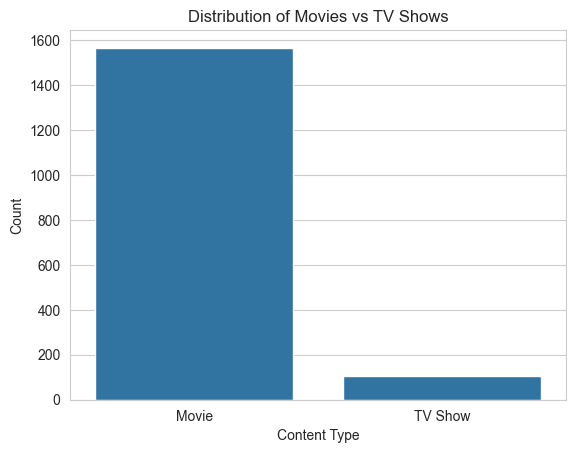

In [18]:
plt.figure()
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()


Movies dominate the dataset, indicating that Netflix has more movie content than TV shows.

# top 10 genre

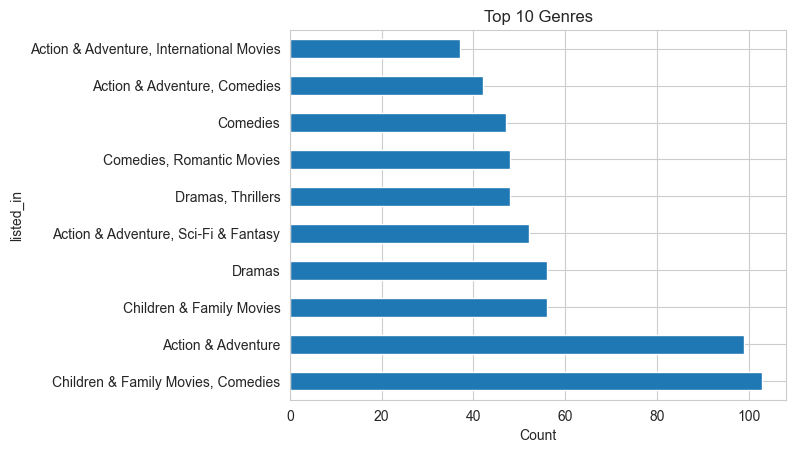

In [19]:
plt.figure()
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.show()


Drama and international content appear most frequently, which helps in building better recommendations.

 # Content Growth Over Years

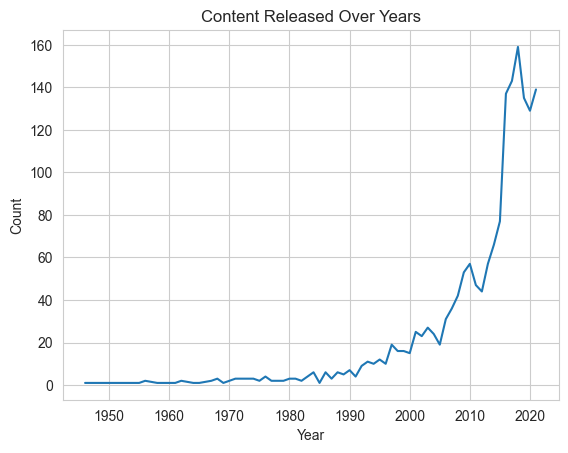

In [20]:
plt.figure()
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


There is a significant rise in content after 2015, showing Netflix’s expansion phase

# Top 10 Countries

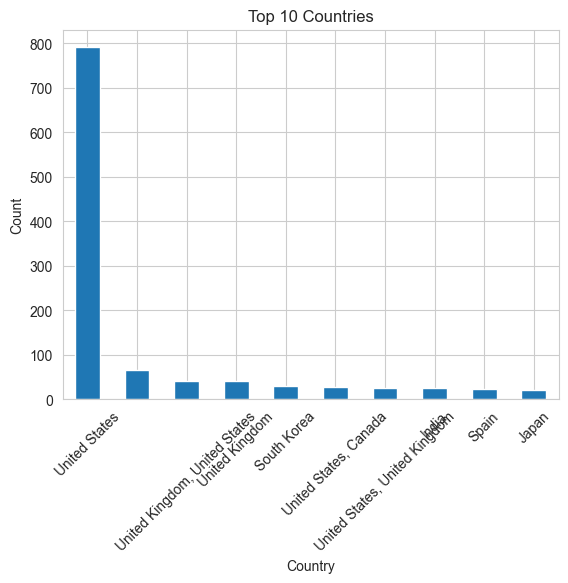

In [21]:
plt.figure()
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


The US produces the majority of content, followed by other countries, showing global distribution

# Ratings Distribution

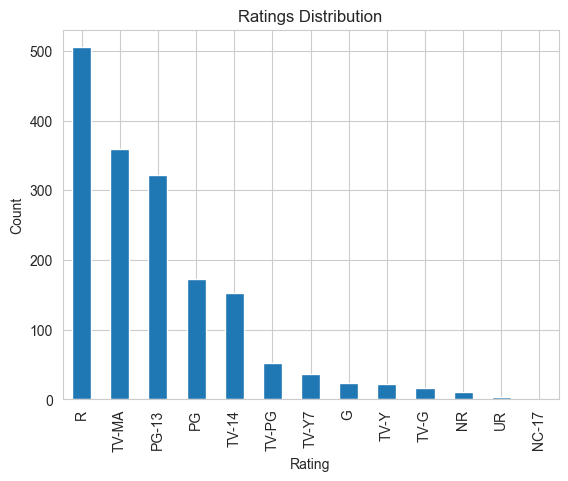

In [22]:
plt.figure()
df['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


Most content is targeted towards mature audiences (TV-MA, TV-14), which reflects Netflix’s audience base

# Duration Analysis (Movies)

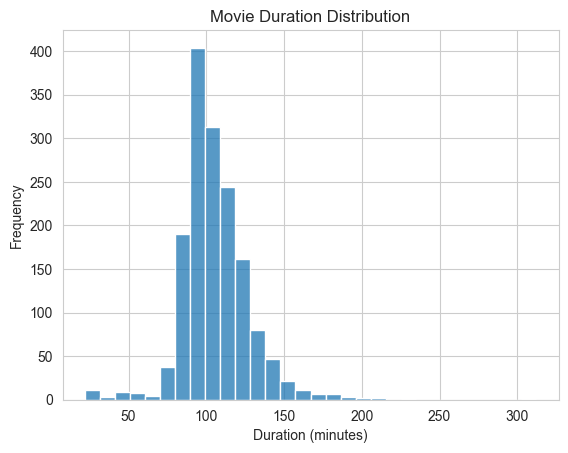

In [23]:
movies = df[df['type'] == 'Movie']

movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

plt.figure()
sns.histplot(movies['duration'], bins=30)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()


Most movies fall in the 80–120 minute range, which is standard industry length

# Heatmap 

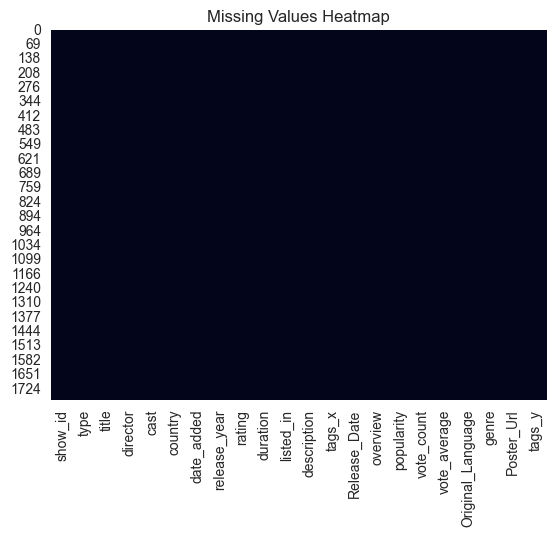

In [24]:
plt.figure()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


# Genre Splitting

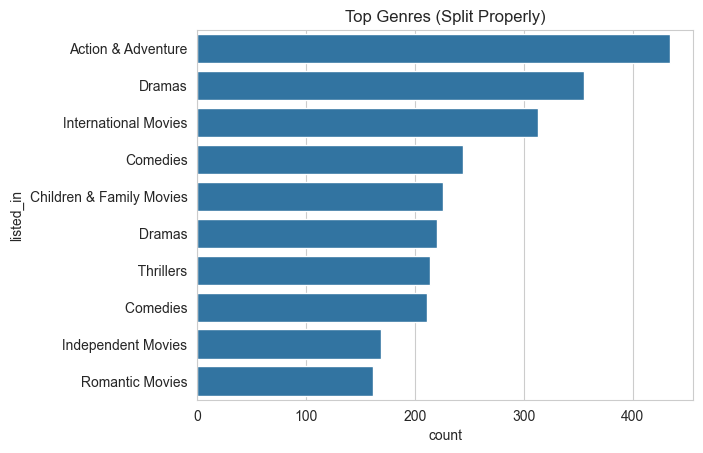

In [25]:
# split genres
df['listed_in'] = df['listed_in'].str.split(',')

# explode
genre_df = df.explode('listed_in')

#  FIX: reset index
genre_df = genre_df.reset_index(drop=True)

# plot
plt.figure()
sns.countplot(
    y='listed_in',
    data=genre_df,
    order=genre_df['listed_in'].value_counts().index[:10]
)
plt.title("Top Genres (Split Properly)")
plt.show()


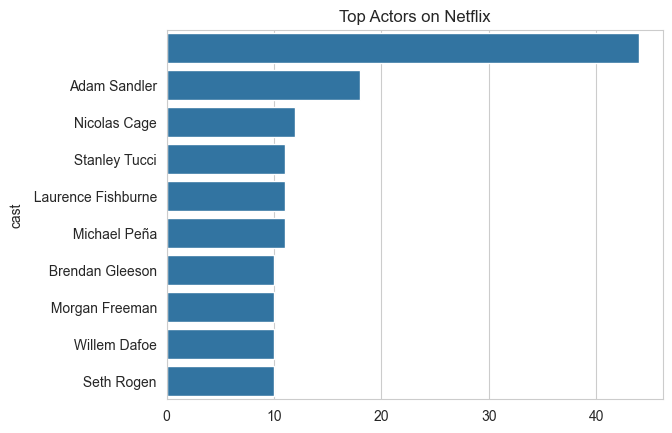

In [26]:
df['cast'] = df['cast'].str.split(',')
cast_df = df.explode('cast')

top_cast = cast_df['cast'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_cast.values, y=top_cast.index)
plt.title("Top Actors on Netflix")
plt.show()


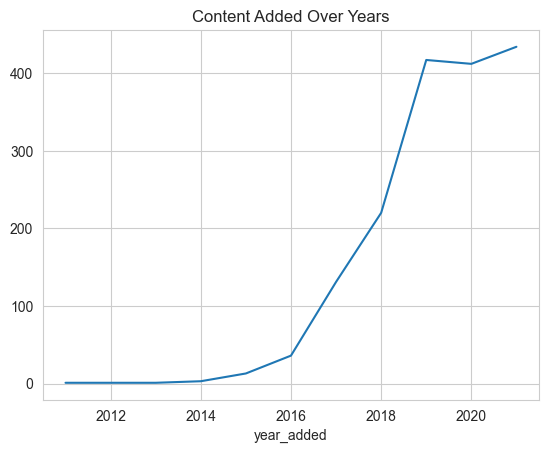

In [27]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

plt.figure()
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added Over Years")
plt.show()


In [28]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'tags_x', 'Release_Date', 'overview', 'popularity', 'vote_count',
       'vote_average', 'Original_Language', 'genre', 'Poster_Url', 'tags_y',
       'year_added'],
      dtype='str')


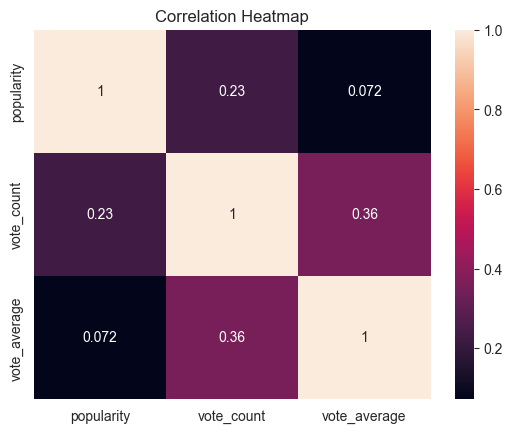

In [29]:
num_df = df[['popularity', 'vote_count', 'vote_average']]

plt.figure()
sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


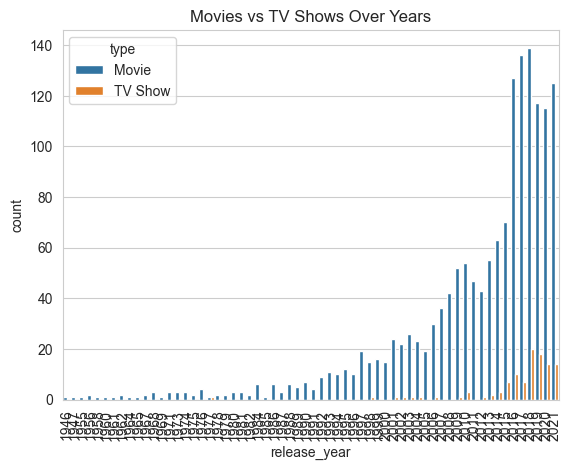

In [30]:
plt.figure()
sns.countplot(x='release_year', hue='type', data=df)
plt.xticks(rotation=90)
plt.title("Movies vs TV Shows Over Years")
plt.show()


In [31]:
df.describe()

,date_added,release_year,popularity,vote_count,vote_average,year_added
count,1668,1673.000000,1673.000000,1673.000000,1673.000000,1668.000000
mean,2019-11-08 02:08:37.985611,2011.547519,35.324011,1801.947400,6.515003,2019.365108
min,2011-09-27 00:00:00,1946.000000,13.378000,0.000000,0.000000,2011.000000
25%,2019-01-01 00:00:00,2008.000000,17.344000,275.000000,6.000000,2019.000000
50%,2020-01-01 00:00:00,2016.000000,23.148000,838.000000,6.500000,2020.000000
75%,2021-01-01 00:00:00,2018.000000,37.905000,2151.000000,7.100000,2021.000000
max,2021-09-24 00:00:00,2021.000000,1675.161000,31077.000000,9.000000,2021.000000
std,NaN,10.590815,51.257975,2741.335842,0.871620,1.423230


In [32]:
(df.isnull().sum()/len(df))*100

show_id              0.000000
type                 0.000000
title                0.000000
director             0.000000
cast                 0.000000
country              0.000000
date_added           0.298864
release_year         0.000000
rating               0.000000
duration             0.000000
listed_in            0.000000
description          0.000000
tags_x               0.000000
Release_Date         0.000000
overview             0.000000
popularity           0.000000
vote_count           0.000000
vote_average         0.000000
Original_Language    0.000000
genre                0.000000
Poster_Url           0.000000
tags_y               0.000000
year_added           0.298864
dtype: float64

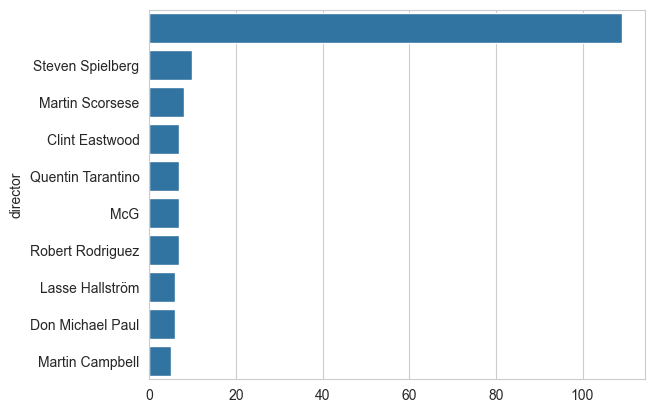

In [33]:
df['director']=df['director'].fillna('Unknown')

top_directors=df['director'].value_counts().head(10)

sns.barplot(
x=top_directors.values,
y=top_directors.index
)
plt.show()

Observation:
Movies dominate dataset
Drama is common genre
Content grew after 2015